# J-score and finite design space
Crosses the curated drug library with the 144-row microneedle matrix. J is an analytical proxy, not a measured delivery outcome. Min-max normalization is defined over the complete constructed drug-by-design dataset.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT=Path("..").resolve()
RAW=ROOT/"data/raw"; PROC=ROOT/"data/processed/final"
FIG=ROOT/"results/final/figures"; TAB=ROOT/"results/final/tables"
for p in (PROC,FIG,TAB): p.mkdir(parents=True,exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["savefig.dpi"]=300

In [2]:
drug=pd.read_csv(PROC/"clean_drug_data.csv"); mn=pd.read_csv(PROC/"clean_mn_data.csv")
df=drug.merge(mn,how="cross")
df["J_Score"]=(df["Concentration_pct"]/np.sqrt(df["MW_g_mol"].clip(lower=1e-6)))*df["Density_cm2"]*df["Inner_diameter_um"]**2*df["Length_um"]
lo,hi=df.J_Score.min(),df.J_Score.max()
if hi<=lo: raise ValueError("J-score range is zero.")
df["J_Score_Normalized"]=(df.J_Score-lo)/(hi-lo)
df.to_csv(PROC/"combined_combinations.csv",index=False,encoding="utf-8-sig")
print("Rows:",len(df),"J formula: (C/sqrt(MW)) * N * inner_diameter^2 * length")
for c in ["Length_um","Base_size_um","Tip_diameter_um","Inner_diameter_um","Cone_radius_um","Density_cm2","Insertion_speed_mm_s","Concentration_pct"]: print(c,sorted(mn[c].unique()))
print("MW range:",drug.MW_g_mol.min(),drug.MW_g_mol.max(),"J range:",lo,hi)

Rows: 3744 J formula: (C/sqrt(MW)) * N * inner_diameter^2 * length
Length_um [np.int64(350), np.int64(450), np.int64(550), np.int64(650)]
Base_size_um [np.int64(100), np.int64(300)]
Tip_diameter_um [np.float64(1.44), np.float64(1.93), np.float64(2.42)]
Inner_diameter_um [np.int64(50), np.int64(150)]
Cone_radius_um [np.float64(2.88), np.float64(3.86), np.float64(4.84)]
Density_cm2 [np.int64(150), np.int64(500), np.int64(900)]
Insertion_speed_mm_s [np.int64(5)]
Concentration_pct [np.float64(0.5)]
MW range: 131.13 6046.0 J range: 843986.0045942955 574721385.9026512


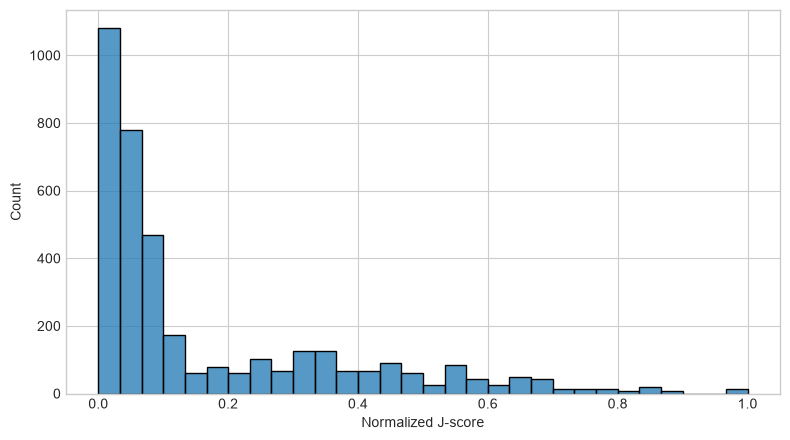

In [3]:
top=df.nlargest(10,"J_Score_Normalized").copy(); top.insert(0,"Rank",range(1,11))
cols=["Rank","Drug","MW_g_mol","Design_ID","Length_um","Base_size_um","Tip_diameter_um","Inner_diameter_um","Cone_radius_um","Density_cm2","Insertion_speed_mm_s","Concentration_pct","J_Score","J_Score_Normalized"]
top[cols].to_csv(TAB/"top_10_combinations.csv",index=False,encoding="utf-8-sig")
plt.figure(figsize=(8,4.5)); sns.histplot(df.J_Score_Normalized,bins=30); plt.xlabel("Normalized J-score"); plt.tight_layout(); plt.savefig(FIG/"j_score_distribution.png"); plt.show()

Features absent from the J-score equation cannot be interpreted as experimentally established transport determinants. The score is a constructed computational objective.